In [2]:
import mujoco, mujoco.viewer
import mediapy as media
import time
import numpy as np

In [3]:
model = mujoco.MjModel.from_xml_path(r"..\external\mujoco_menagerie\unitree_a1\scene.xml")
data = mujoco.MjData(model)

dt = float(model.opt.timestep)

In [4]:
foot_geom_names = ["FR_foot", "FL_foot", "RR_foot", "RL_foot"]
_foot_geom_ids = set(
	mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_GEOM, name)
	for name in foot_geom_names
)
_robot_geom_ids = set(
	i for i in range(model.ngeom)
	if model.geom_bodyid[i] > 0
)

In [5]:
_foot_geom_ids, _robot_geom_ids

({19, 30, 40, 50},
 {1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50})

In [6]:
[model.body(i).name for i in range(model.nbody)]

['world',
 'trunk',
 'FR_hip',
 'FR_thigh',
 'FR_calf',
 'FL_hip',
 'FL_thigh',
 'FL_calf',
 'RR_hip',
 'RR_thigh',
 'RR_calf',
 'RL_hip',
 'RL_thigh',
 'RL_calf']

In [7]:
model.geom(16)

<_MjModelGeomViews
  bodyid: array([4])
  conaffinity: array([0])
  condim: array([3])
  contype: array([0])
  dataid: array([0])
  friction: array([6.e-01, 5.e-03, 1.e-04])
  gap: array([0.])
  group: array([2])
  id: 16
  margin: array([0.001])
  matid: array([0])
  name: ''
  pos: array([ 6.39593168e-03,  2.43584143e-05, -1.24936248e-01])
  priority: array([0])
  quat: array([ 0.70653898, -0.00091099, -0.00071315,  0.70767318])
  rbound: array([0.15980149])
  rgba: array([0.5, 0.5, 0.5, 1. ], dtype=float32)
  sameframe: array([0], dtype=uint8)
  size: array([0.0200026 , 0.02656766, 0.15630282])
  solimp: array([9.0e-01, 9.5e-01, 1.0e-03, 5.0e-01, 2.0e+00])
  solmix: array([1.])
  solref: array([0.02, 1.  ])
  type: array([7])
  user: array([], dtype=float64)
>

In [8]:
[(i, model.geom(i).name) for i in range(model.ngeom)]

[(0, 'floor'),
 (1, ''),
 (2, ''),
 (3, ''),
 (4, ''),
 (5, ''),
 (6, ''),
 (7, ''),
 (8, ''),
 (9, ''),
 (10, ''),
 (11, ''),
 (12, ''),
 (13, ''),
 (14, ''),
 (15, ''),
 (16, ''),
 (17, ''),
 (18, ''),
 (19, 'FR_foot'),
 (20, ''),
 (21, ''),
 (22, ''),
 (23, ''),
 (24, ''),
 (25, ''),
 (26, ''),
 (27, ''),
 (28, ''),
 (29, ''),
 (30, 'FL_foot'),
 (31, ''),
 (32, ''),
 (33, ''),
 (34, ''),
 (35, ''),
 (36, ''),
 (37, ''),
 (38, ''),
 (39, ''),
 (40, 'RR_foot'),
 (41, ''),
 (42, ''),
 (43, ''),
 (44, ''),
 (45, ''),
 (46, ''),
 (47, ''),
 (48, ''),
 (49, ''),
 (50, 'RL_foot')]

Image

""

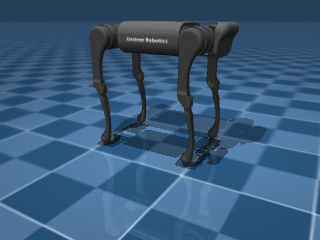

In [9]:
with mujoco.Renderer(model) as renderer:
	mujoco.mj_forward(model, data)
	# mujoco.mj_step(model, data)
	renderer.update_scene(data)
	
	media.show_image(renderer.render())

In [10]:
data.qpos[0:3]

array([0.  , 0.  , 0.43])

In [11]:
data.qpos[2] = 0.15

In [12]:
mujoco.mj_resetDataKeyframe(model, data, 0)

In [13]:
mujoco.mj_resetData(model, data)

Video

In [14]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetDataKeyframe(model, data, 0)  # Reset state and time.
data.ctrl[:] = np.array([
    -0.1, 0.8, -1.5,   # Front Right
     0.1, 0.8, -1.5,   # Front Left
    -0.1, 1.0, -1.5,   # Rear Right
     0.1, 1.0, -1.5    # Rear Left
], dtype=np.float32)
with mujoco.Renderer(model) as renderer:
	while data.time < duration:
		mujoco.mj_step(model, data)
		if len(frames) < data.time * framerate:
			#   print(data.time)
			# print(data.qpos[0:3])
			renderer.update_scene(data)
			pixels = renderer.render()
			frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


In [15]:
data.ctrl[:]

array([-0.1       ,  0.80000001, -1.5       ,  0.1       ,  0.80000001,
       -1.5       , -0.1       ,  1.        , -1.5       ,  0.1       ,
        1.        , -1.5       ])

Live Render

In [ ]:
SPEED_MULTIPLIER = 1

with mujoco.viewer.launch_passive(model, data) as viewer:
	while viewer.is_running():
		t0 = time.perf_counter()
		mujoco.mj_step(model, data)
		viewer.sync()
		action = data.ctrl[:]
		FR, FL, RR, RL = action[0:3], action[3:6], action[6:9], action[9:12]
		FR[0] *= -1
		RR[0] *= -1
		print(f"FR: {FR}, FL: {FL}, RR: {RR}, RL: {RL}")
		while time.perf_counter() - t0 < dt * SPEED_MULTIPLIER:
			time.sleep(0)

SyntaxError: 'tuple' is an illegal expression for augmented assignment (138220119.py, line 10)

Control Test

In [7]:
model.actuator_ctrlrange

array([[-0.802851,  0.802851],
       [-1.0472  ,  4.18879 ],
       [-2.69653 , -0.916298],
       [-0.802851,  0.802851],
       [-1.0472  ,  4.18879 ],
       [-2.69653 , -0.916298],
       [-0.802851,  0.802851],
       [-1.0472  ,  4.18879 ],
       [-2.69653 , -0.916298],
       [-0.802851,  0.802851],
       [-1.0472  ,  4.18879 ],
       [-2.69653 , -0.916298]])

In [8]:
data.ctrl

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [9]:
data.time

19.208000000000233

In [10]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    for i in range(len(data.ctrl)):
        magnitude = model.actuator_ctrlrange[i, 1] - model.actuator_ctrlrange[i, 0]
        median = 0.5 * (model.actuator_ctrlrange[i, 0] + model.actuator_ctrlrange[i, 1])
        data.ctrl[i] = median + 0.5 * magnitude * np.sin(2 * np.pi * data.time + i*np.pi/4)
        
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


PPO Training

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from env import UnitreeA1Env

xmlPath = r"..\external\mujoco_menagerie\unitree_a1\scene.xml"

In [25]:
# Train live view

env = UnitreeA1Env(xmlPath, render_mode="human")
model = PPO("MlpPolicy", env, verbose=1)

obs, _ = env.reset()
episode_reward = 0
episode_rewards = []

for step in range(50_000):
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, _ = env.step(action)
    env.render()
    episode_reward += reward

    if terminated or truncated:
        episode_rewards.append(episode_reward)
        episode_reward = 0
        obs, _ = env.reset()

        # Print every 10 episodes
        if len(episode_rewards) % 10 == 0:
            mean = sum(episode_rewards[-10:]) / 10
            print(f"Episode {len(episode_rewards)} | Mean reward (last 10): {mean:.2f}")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Episode 10 | Mean reward (last 10): 16.50
Episode 20 | Mean reward (last 10): 57.65
Episode 30 | Mean reward (last 10): 60.50
Episode 40 | Mean reward (last 10): 18.91
Episode 50 | Mean reward (last 10): 28.00
Episode 60 | Mean reward (last 10): 64.59
Episode 70 | Mean reward (last 10): 30.91
Episode 80 | Mean reward (last 10): 41.43
Episode 90 | Mean reward (last 10): 65.95
Episode 100 | Mean reward (last 10): 66.46
Episode 110 | Mean reward (last 10): 64.37
Episode 120 | Mean reward (last 10): 69.41
Episode 130 | Mean reward (last 10): 32.05
Episode 140 | Mean reward (last 10): 26.46
Episode 150 | Mean reward (last 10): 49.11
Episode 160 | Mean reward (last 10): 68.68
Episode 170 | Mean reward (last 10): 75.07
Episode 180 | Mean reward (last 10): 16.30
Episode 190 | Mean reward (last 10): 47.01
Episode 200 | Mean reward (last 10): 75.76
Episode 210 | Mean reward (last 10): 69.13


In [ ]:
# Headless training

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback

xml = r"..\external\mujoco_menagerie\unitree_a1\scene.xml"

class LogCallback(BaseCallback):
    def _on_step(self):
        if len(self.model.ep_info_buffer) > 0 and self.n_calls % 10_000 == 0:
            mean_reward = np.mean([e["r"] for e in self.model.ep_info_buffer])
            mean_len    = np.mean([e["l"] for e in self.model.ep_info_buffer])
            print(f"steps={self.num_timesteps:>8} | mean_ep_reward={mean_reward:>8.2f} | mean_ep_len={mean_len:>6.0f}")
        return True

env = make_vec_env(lambda: UnitreeA1Env(xml), n_envs=4)

model = PPO(
    "MlpPolicy",
    env,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,       # small entropy bonus helps exploration
    learning_rate=3e-4,
    verbose=0,           # silence SB3's own output, use our callback instead
    tensorboard_log="./tb_logs/",
)

model.learn(total_timesteps=5_000_000, callback=LogCallback())
model.save("a1_walk_v1")

steps=   40000 | mean_ep_reward=   66.01 | mean_ep_len=   250
steps=   80000 | mean_ep_reward=  142.86 | mean_ep_len=   262
steps=  120000 | mean_ep_reward=  161.48 | mean_ep_len=   222
steps=  160000 | mean_ep_reward=  218.52 | mean_ep_len=   233
steps=  200000 | mean_ep_reward=  280.58 | mean_ep_len=   244
steps=  240000 | mean_ep_reward=  310.65 | mean_ep_len=   252
steps=  280000 | mean_ep_reward=  316.48 | mean_ep_len=   245
steps=  320000 | mean_ep_reward=  361.54 | mean_ep_len=   280
steps=  360000 | mean_ep_reward=  398.41 | mean_ep_len=   297
steps=  400000 | mean_ep_reward=  431.21 | mean_ep_len=   320
steps=  440000 | mean_ep_reward=  515.67 | mean_ep_len=   366
steps=  480000 | mean_ep_reward=  537.17 | mean_ep_len=   393
steps=  520000 | mean_ep_reward=  609.80 | mean_ep_len=   465
steps=  560000 | mean_ep_reward=  682.10 | mean_ep_len=   515
steps=  600000 | mean_ep_reward=  837.10 | mean_ep_len=   599
steps=  640000 | mean_ep_reward=  907.74 | mean_ep_len=   626
steps=  

Load a model

In [ ]:
from stable_baselines3 import PPO
import numpy as np

# Load the trained model
model = PPO.load(r"..\Models\a1_walk_v1")

# Create a render env
env = UnitreeA1Env(xml, render_mode="human")
obs, _ = env.reset()

while True:
    action, _ = model.predict(obs, deterministic=True)  # deterministic=True = no random sampling
    obs, reward, terminated, truncated, _ = env.step(action)
    env.render()
    if terminated or truncated:
        obs, _ = env.reset()

KeyboardInterrupt: 

export a 10 second video at 60 FPS of the model

In [ ]:
from record_video import record_video
record_video(
    model_path="a1_walk_v1",
	env=UnitreeA1Env,
    xml_path=r".\external\mujoco_menagerie\unitree_a1\scene.xml",
    output_path="a1_progress_5m_steps.mp4",
    duration_seconds=10,
    fps=60
)

Saved 10s video (600 frames) to a1_progress_5m_steps.mp4
